# Presidents Report Figures

This notebook regenerates the figures used in the presidents report from grouped cross-validation, out-of-fold predictions, and training logs.

The goal is to make the main report figures easy to inspect and adjust interactively before export.


In [1]:
from pathlib import Path
import importlib.util
import sys

import matplotlib
INLINE_BACKEND = "module://matplotlib_inline.backend_inline"
matplotlib.use(INLINE_BACKEND)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from io import BytesIO
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

src_path = str(ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from rital_nlp_project.common.notebook_utils import init_notebook

init_notebook()

spec = importlib.util.spec_from_file_location(
    "presidents_report_assets",
    ROOT / "scripts/build_presidents_report_assets.py",
)
assets = importlib.util.module_from_spec(spec)
spec.loader.exec_module(assets)

# The batch script uses a non-interactive backend; switch back for notebook rendering.
plt.switch_backend(INLINE_BACKEND)
assets.configure_plot_style()
plt.rcParams["figure.dpi"] = 140

EXPORT_DIR = ROOT / "Dataset/out/presidents_report_assets/notebook_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, stem, export_dir=EXPORT_DIR):
    png_path = export_dir / f"{stem}.png"
    pdf_path = export_dir / f"{stem}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")
    return png_path, pdf_path

def render_figure(fig, dpi=220):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))
    return fig

print(f"Project root: {ROOT}")
print(f"Notebook export directory: {EXPORT_DIR}")


Project root: /home/paulbeglin/projects/RITAL-NLP-project
Notebook export directory: /home/paulbeglin/projects/RITAL-NLP-project/Dataset/out/presidents_report_assets/notebook_exports


In [2]:
simple_sweep_frame = assets.aggregate_simple_sweep_runs()
camembert_train_dir = assets.locate_camembert_train_dir()
model_comparison_frame = assets.aggregate_report_safe_model_comparison(
    simple_sweep_frame,
    camembert_train_dir,
)

best_run_dir = Path(assets.load_json(assets.SIMPLE_SWEEP_SUMMARY)["best_ranked_run"]["output_dir"])
best_run_oof = pd.read_csv(best_run_dir / "oof_predictions.csv")
best_run_calibration = assets.load_json(best_run_dir / "calibration.json")
best_run_threshold = float(best_run_calibration["threshold"])
best_fold_metrics = assets.compute_fold_metrics(best_run_oof, best_run_threshold)

clean_main_oof = pd.read_csv(assets.CLEAN_MAIN_SIMPLE_TRAIN_DIR / "oof_predictions.csv")
clean_main_calibration = assets.load_json(assets.CLEAN_MAIN_SIMPLE_TRAIN_DIR / "calibration.json")
speech_metrics = assets.compute_speech_block_metrics(
    clean_main_oof,
    "prob_mitterrand_raw",
    float(clean_main_calibration["threshold"]),
)
clean_example_speech, noisy_example_speech = assets.choose_example_speeches(speech_metrics)

fusion_source_dir = (
    ROOT / "Dataset/out/presidents_bilstm_camembert_fusion_main_full"
    if (ROOT / "Dataset/out/presidents_bilstm_camembert_fusion_main_full/metrics.json").exists()
    else assets.FUSION_FULLCHECK_DIR
)
fusion_metrics = assets.load_json(fusion_source_dir / "metrics.json")
trajectory_frame = assets.build_trajectory_frame(
    clean_main_threshold=float(clean_main_calibration["threshold"]),
    cam_threshold=float(assets.load_json(camembert_train_dir / "calibration.json")["threshold"]),
    fusion_alpha=float(fusion_metrics["calibration"]["alpha"]),
    fusion_threshold=float(fusion_metrics["calibration"]["threshold"]),
    camembert_train_dir=camembert_train_dir,
)

print("Report data loaded.")
display(simple_sweep_frame.head(3))
display(model_comparison_frame)


Report data loaded.


,plot_id,rank_oof_tuned_f1,run_name,short_label,hidden_dim,projection_dim,dropout,minority_weight_scale,epochs,best_epoch,...,oof_precision_macro_tuned,oof_recall_macro_tuned,oof_f1_macro_tuned,oof_roc_auc,oof_pr_auc,oof_accuracy_0p5,oof_f1_macro_0p5,start_lag_mean,end_lag_mean,multi_block_speeches
0,R1,1,presidents_lstm_simple_tuned_hd128_pd256_do0p1...,"hd=128, pd=256, do=0.15, mw=0.7, ep=20",128,256,0.15,0.7,20,20,...,0.936576,0.921637,0.928919,0.986194,0.942267,0.960357,0.917627,-0.158730,0.560847,51
1,R2,9,presidents_lstm_simple_tuned_hd256_pd512_do0p1...,"hd=256, pd=512, do=0.15, mw=0.7, ep=16",256,512,0.15,0.7,16,16,...,0.930903,0.920392,0.925554,0.986036,0.937969,0.961577,0.918749,0.130890,0.565445,62
2,R3,4,presidents_lstm_simple_tuned_hd128_pd512_do0p2...,"hd=128, pd=512, do=0.20, mw=0.7, ep=20",128,512,0.20,0.7,20,19,...,0.927149,0.917801,0.922400,0.985138,0.938277,0.962953,0.920468,-0.047872,0.992021,59


,model,oof_accuracy,oof_balanced_accuracy,oof_precision_macro,oof_recall_macro,oof_f1_macro,oof_roc_auc,oof_pr_auc,threshold,alpha
0,Simple BiLSTM (Sweep Winner),0.968178,0.921637,0.936576,0.921637,0.928919,0.986194,0.942267,0.855,NaN
1,Simple BiLSTM (Clean Main Rerun),0.964468,0.923058,0.921252,0.923058,0.922152,0.984407,0.933910,0.780,NaN
2,CamemBERT Context Classifier,0.951631,0.821867,0.963149,0.821867,0.875324,0.952135,0.905179,0.050,NaN
3,Weighted BiLSTM + CamemBERT Fusion,0.974135,0.931724,0.952723,0.931724,0.941868,0.988818,0.958007,0.075,0.55


## 1. Hyperparameter Sweep Ranking

This is the main model-selection figure for the simple BiLSTM sweep. The label offsets, font size, and title are all easy to adjust in the cell below.


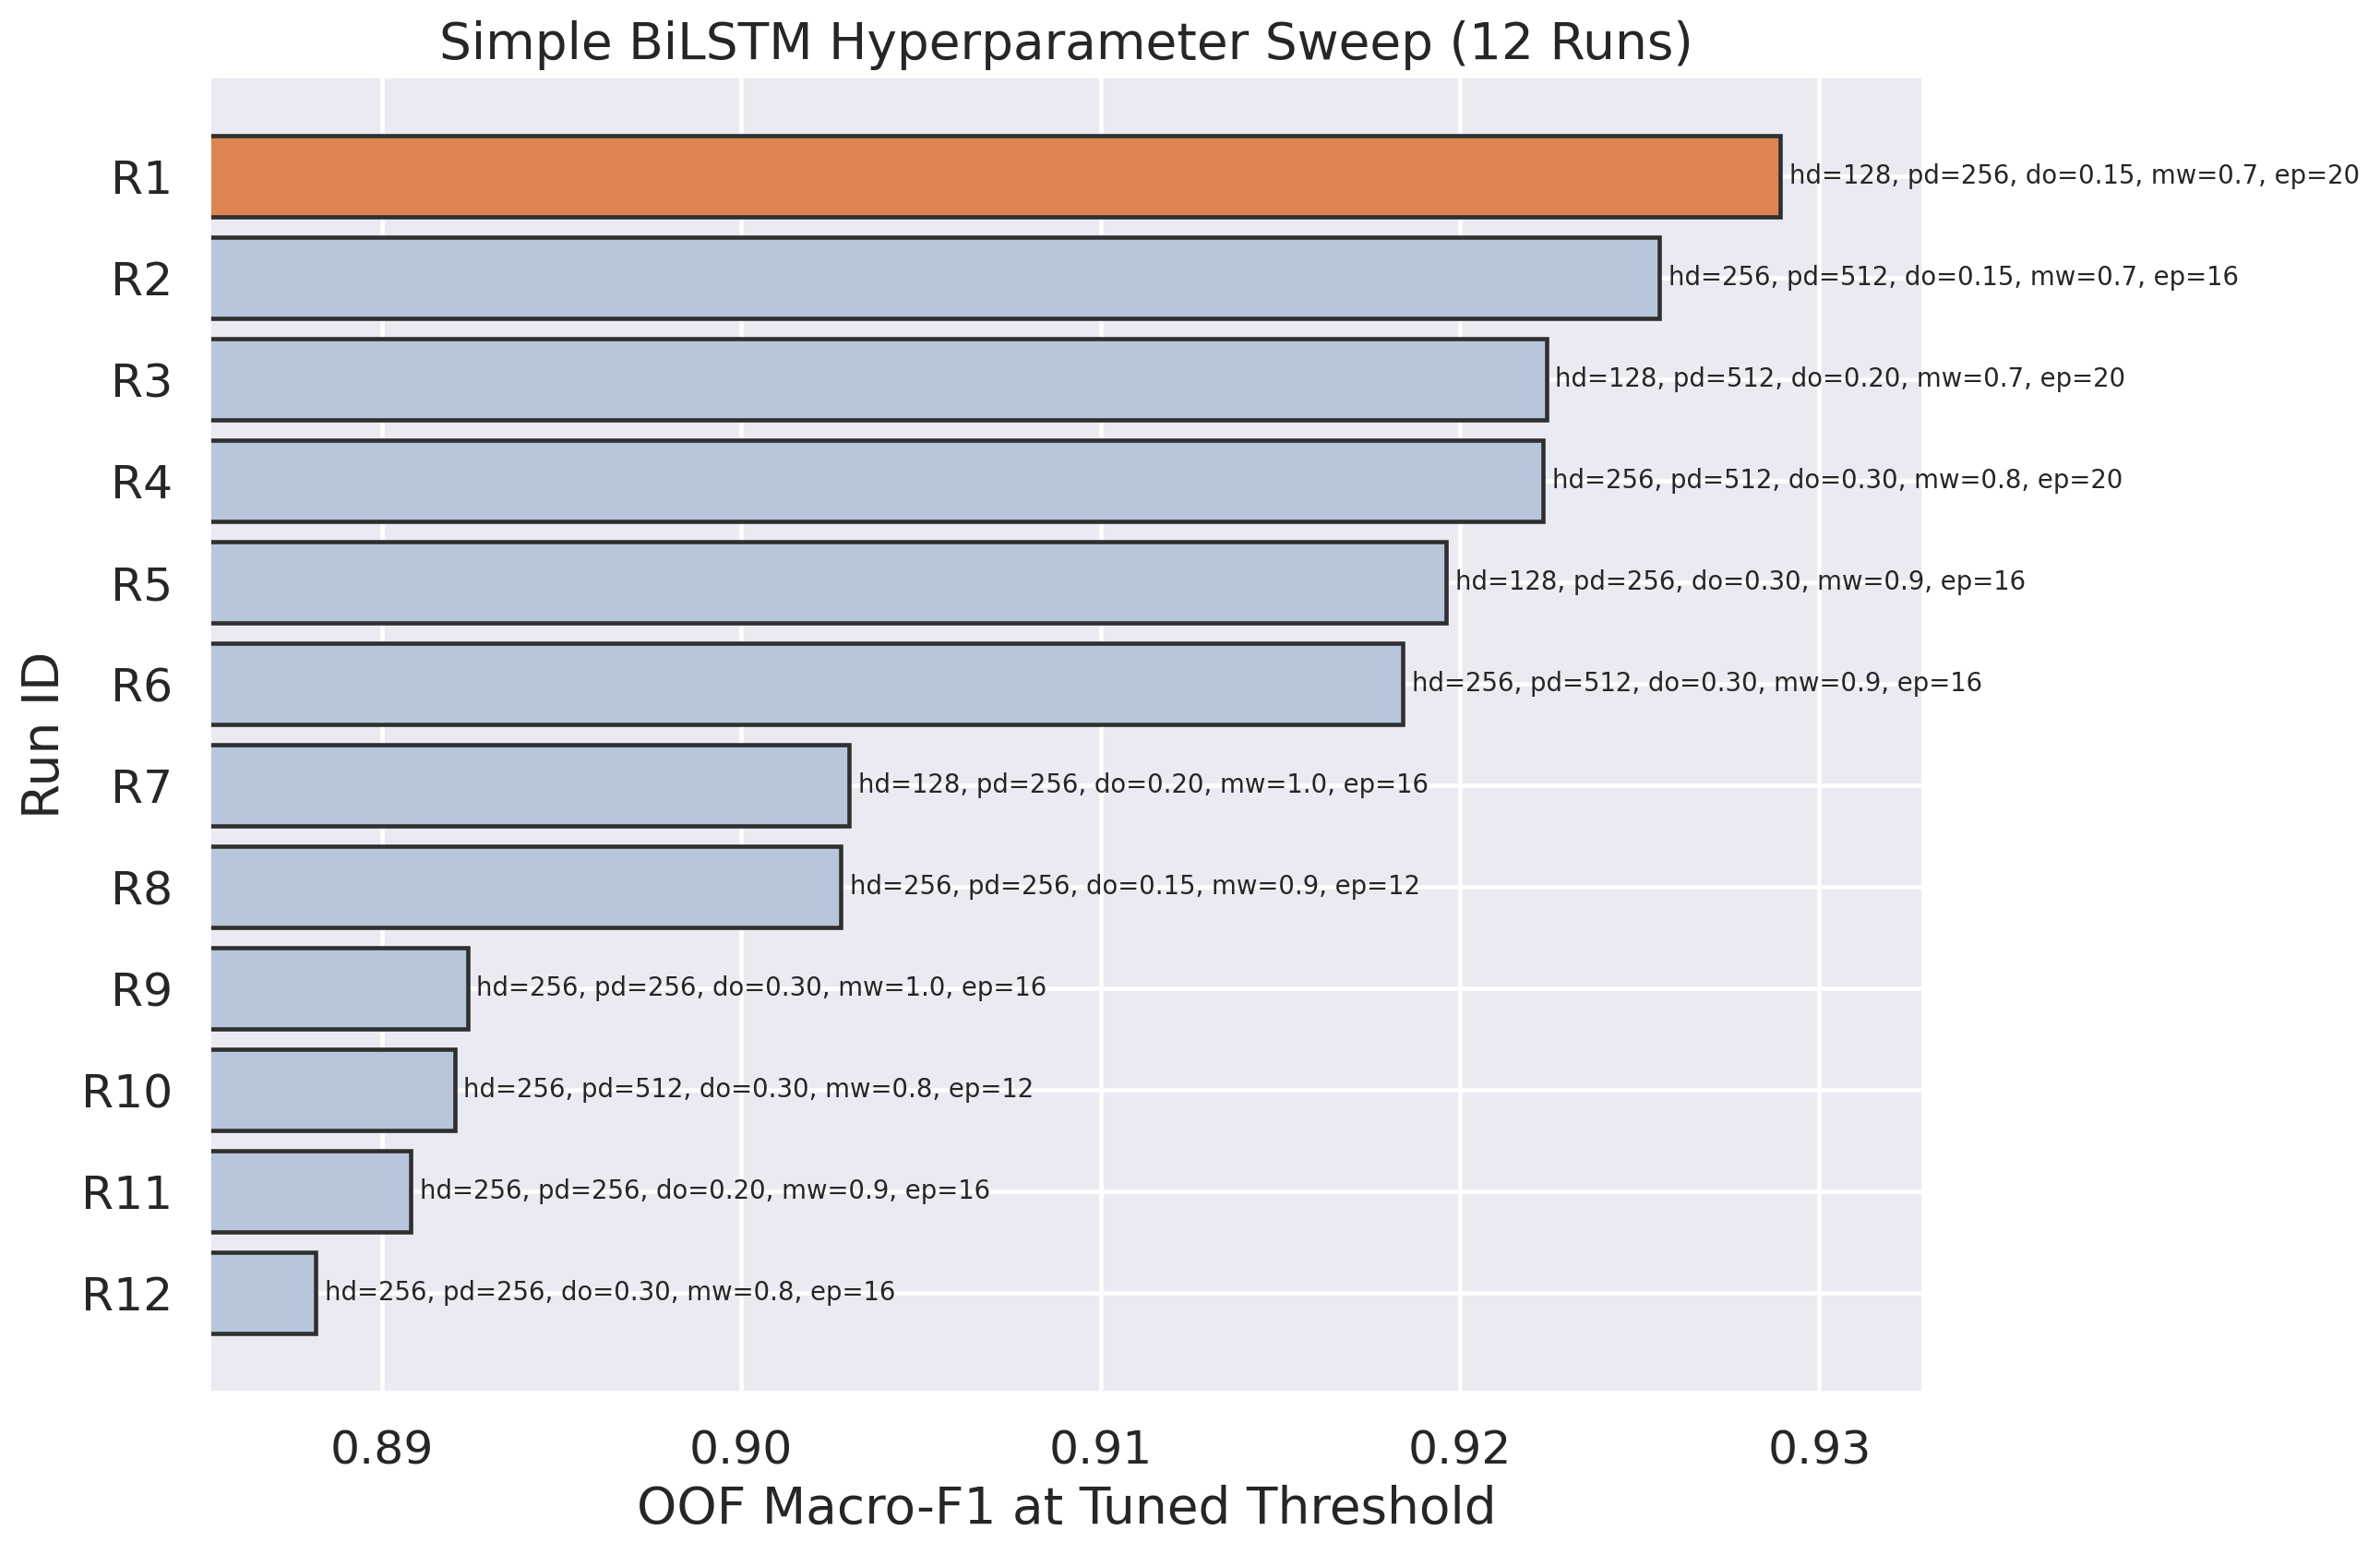

In [3]:
plot_frame = simple_sweep_frame.sort_values("oof_f1_macro_tuned", ascending=True).copy()

figsize = (12, 8)
text_dx = 0.00025
text_fontsize = 9
title = "Simple BiLSTM Hyperparameter Sweep (12 Runs)"
highlight_run_id = "R1"
bar_color = "#b8c6db"
highlight_color = "#dd8452"

fig, ax = plt.subplots(figsize=figsize)
colors = [bar_color] * len(plot_frame)
highlight_pos = plot_frame.index[plot_frame["plot_id"] == highlight_run_id][0]
colors[list(plot_frame.index).index(highlight_pos)] = highlight_color

ax.barh(plot_frame["plot_id"], plot_frame["oof_f1_macro_tuned"], color=colors, edgecolor="#2f2f2f")
ax.set_xlabel("OOF Macro-F1 at Tuned Threshold")
ax.set_ylabel("Run ID")
ax.set_title(title)
ax.set_xlim(plot_frame["oof_f1_macro_tuned"].min() - 0.003, plot_frame["oof_f1_macro_tuned"].max() + 0.004)

for _, row in plot_frame.iterrows():
    ax.text(
        row["oof_f1_macro_tuned"] + text_dx,
        row["plot_id"],
        row["short_label"],
        va="center",
        fontsize=text_fontsize,
    )

fig.tight_layout()
render_figure(fig)
plt.close(fig)
# save_figure(fig, "simple_sweep_ranking_oof_custom")


## 2. Threshold Calibration

This figure explains why the final decision threshold is not fixed at 0.5.


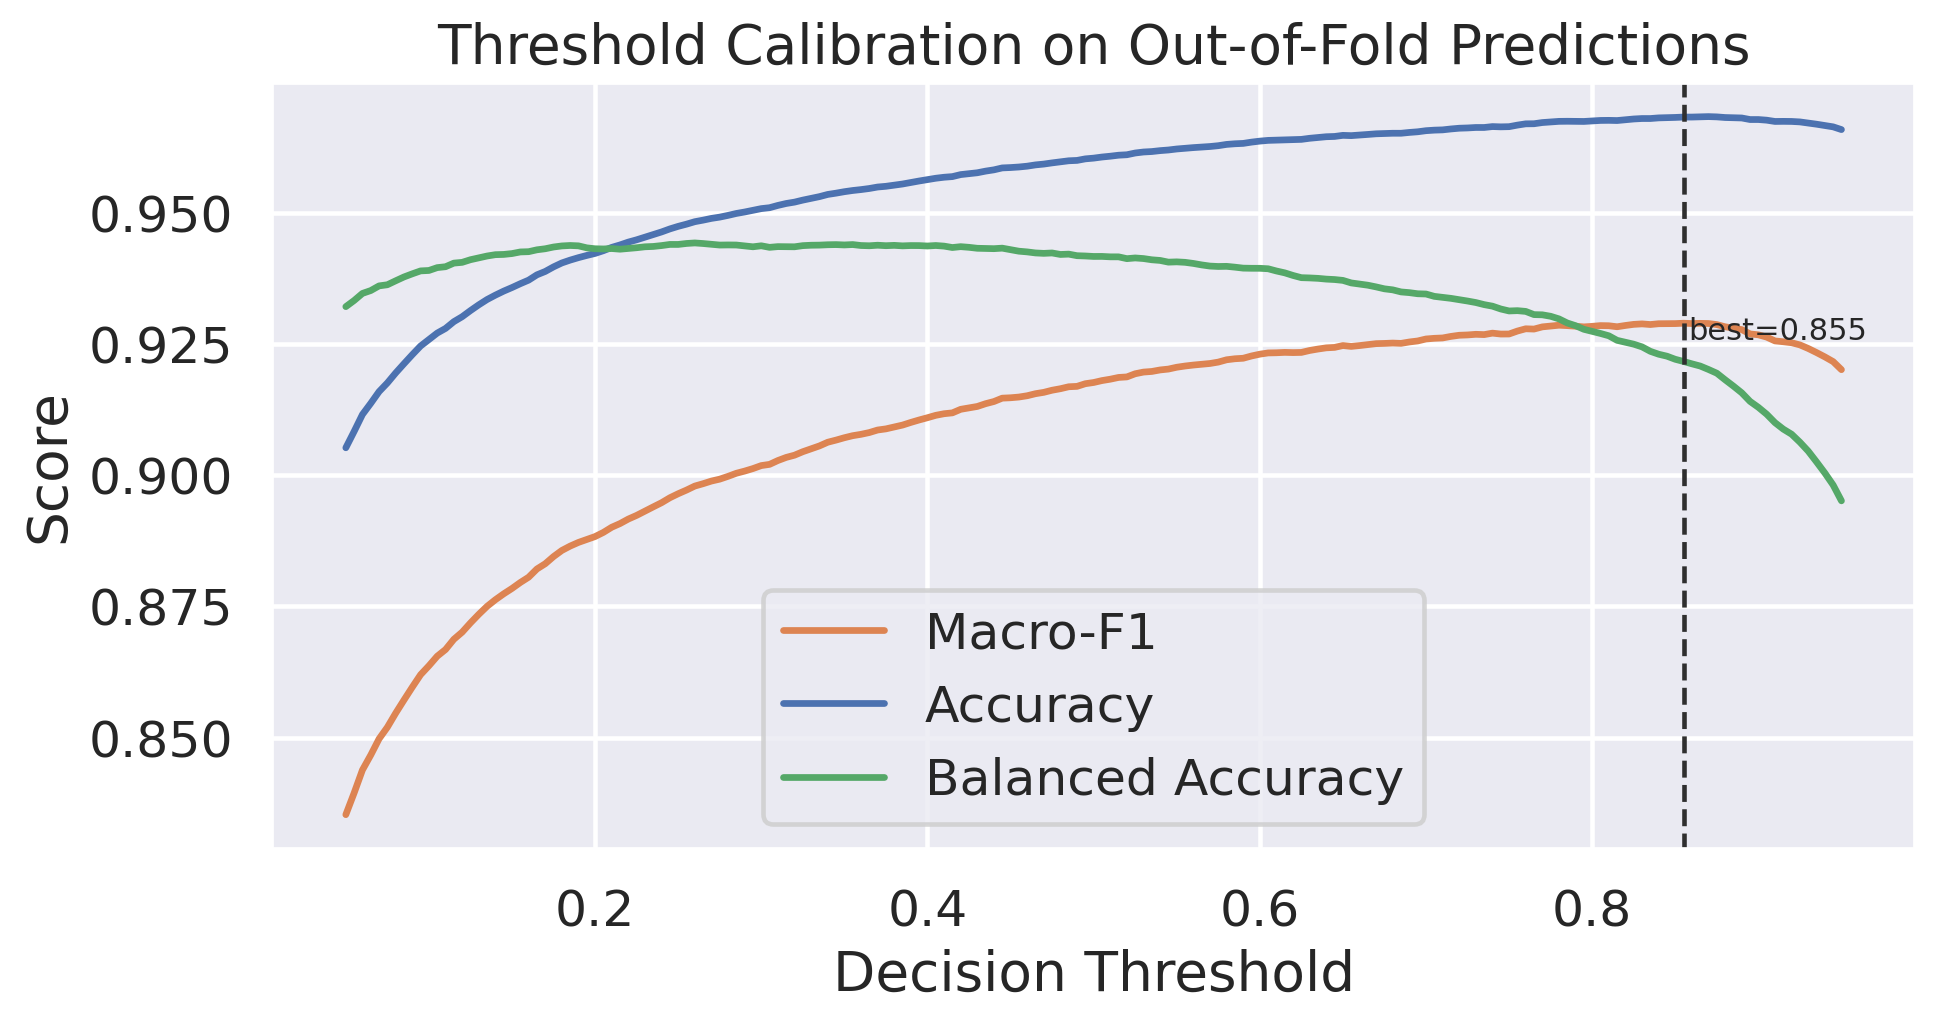

In [4]:
sweep = pd.read_csv(best_run_dir / "threshold_sweep.csv")
best_row = sweep.sort_values(["f1_macro", "balanced_accuracy", "threshold"], ascending=[False, False, True]).iloc[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep["threshold"], sweep["f1_macro"], label="Macro-F1", linewidth=2.2, color="#dd8452")
ax.plot(sweep["threshold"], sweep["accuracy"], label="Accuracy", linewidth=2.2, color="#4c72b0")
ax.plot(sweep["threshold"], sweep["balanced_accuracy"], label="Balanced Accuracy", linewidth=2.2, color="#55a868")
ax.axvline(best_row["threshold"], color="#2f2f2f", linestyle="--", linewidth=1.5)
ax.text(float(best_row["threshold"]) + 0.003, float(best_row["f1_macro"]) - 0.003, f"best={best_row['threshold']:.3f}", fontsize=10)
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Calibration on Out-of-Fold Predictions")
ax.legend(frameon=True)
fig.tight_layout()
render_figure(fig)
plt.close(fig)
# save_figure(fig, "simple_threshold_sweep_custom")


## 3. Epoch Selection

This plot compares the tuned-threshold validation score, the 0.5-threshold validation score, and the training loss across epochs.


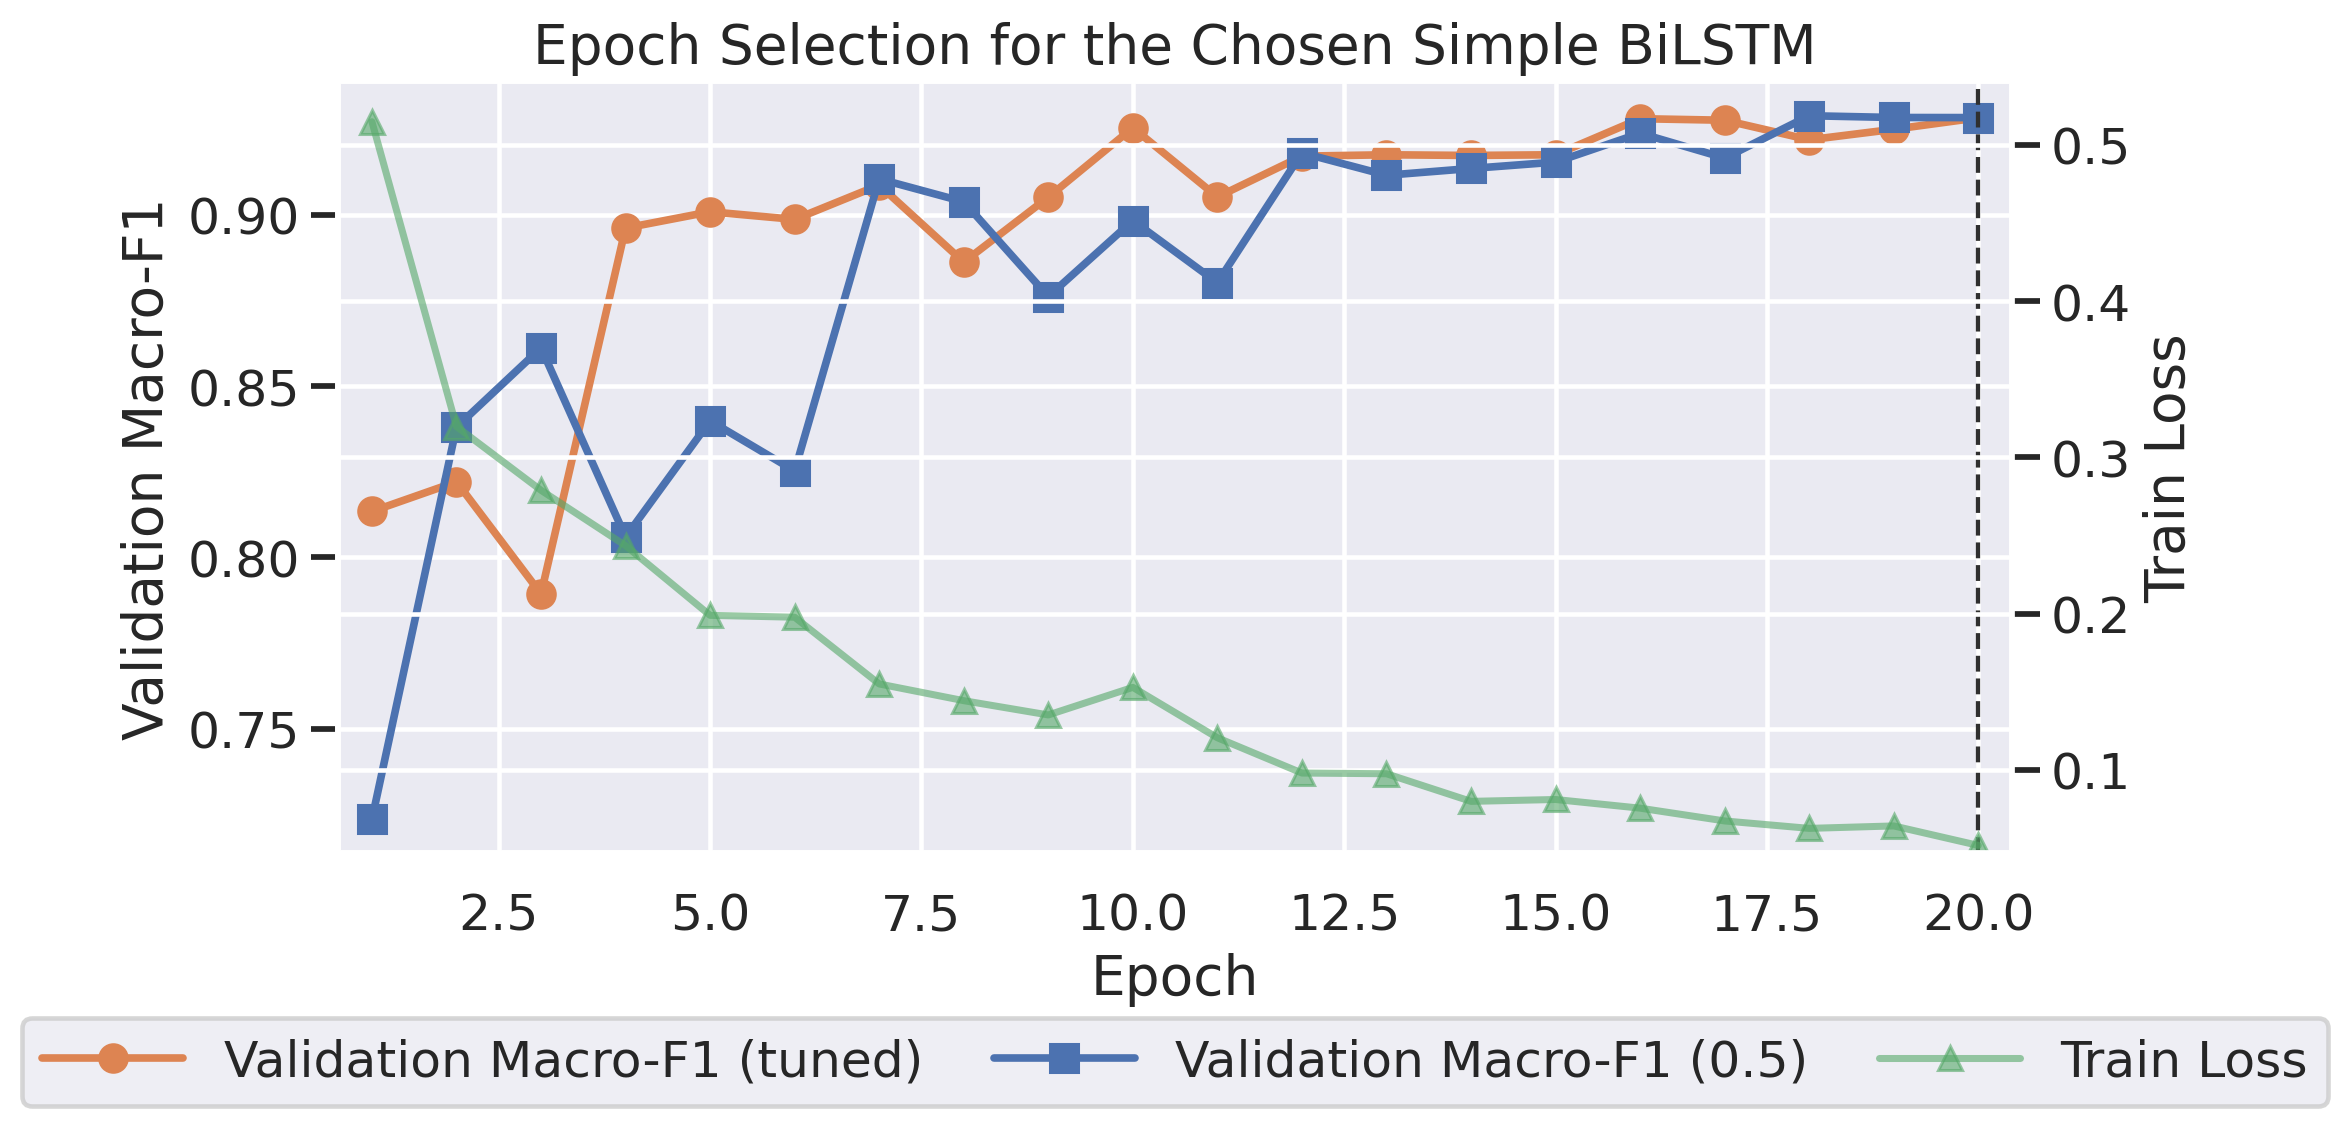

In [5]:
history = pd.read_json(best_run_dir / "history.jsonl", lines=True)
history["validation_f1_tuned"] = history["validation_selection"].map(lambda value: value["f1_macro"])
history["validation_f1_0p5"] = history["validation_metrics_at_0p5"].map(lambda value: value["f1_macro"])
best_epoch = int(history.loc[history["validation_f1_tuned"].idxmax(), "epoch"])

fig, ax1 = plt.subplots(figsize=(10.5, 6.2))
ax1.plot(history["epoch"], history["validation_f1_tuned"], marker="o", linewidth=2.5, markersize=9, label="Validation Macro-F1 (tuned)", color="#dd8452")
ax1.plot(history["epoch"], history["validation_f1_0p5"], marker="s", linewidth=2.5, markersize=9, label="Validation Macro-F1 (0.5)", color="#4c72b0")
ax1.axvline(best_epoch, color="#2f2f2f", linestyle="--", linewidth=1.4)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Validation Macro-F1")
ax1.set_title("Epoch Selection for the Chosen Simple BiLSTM")
ax1.set_xlim(history["epoch"].min() - 0.4, history["epoch"].max() + 0.4)
ax1.set_ylim(history[["validation_f1_tuned", "validation_f1_0p5"]].min().min() - 0.01, history[["validation_f1_tuned", "validation_f1_0p5"]].max().max() + 0.01)

ax2 = ax1.twinx()
ax2.plot(history["epoch"], history["train_loss"], marker="^", linewidth=2.3, markersize=8, alpha=0.6, label="Train Loss", color="#55a868")
ax2.set_ylabel("Train Loss")
ax2.set_ylim(history["train_loss"].min() * 0.9, history["train_loss"].max() * 1.05)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=True, columnspacing=1.4, handlelength=2.8)
fig.tight_layout(rect=(0, 0.08, 1, 1))
render_figure(fig)
plt.close(fig)
# save_figure(fig, "simple_epoch_selection_custom")


## 4. Fold Stability

This heatmap summarizes the selected simple BiLSTM across the five grouped out-of-fold splits.


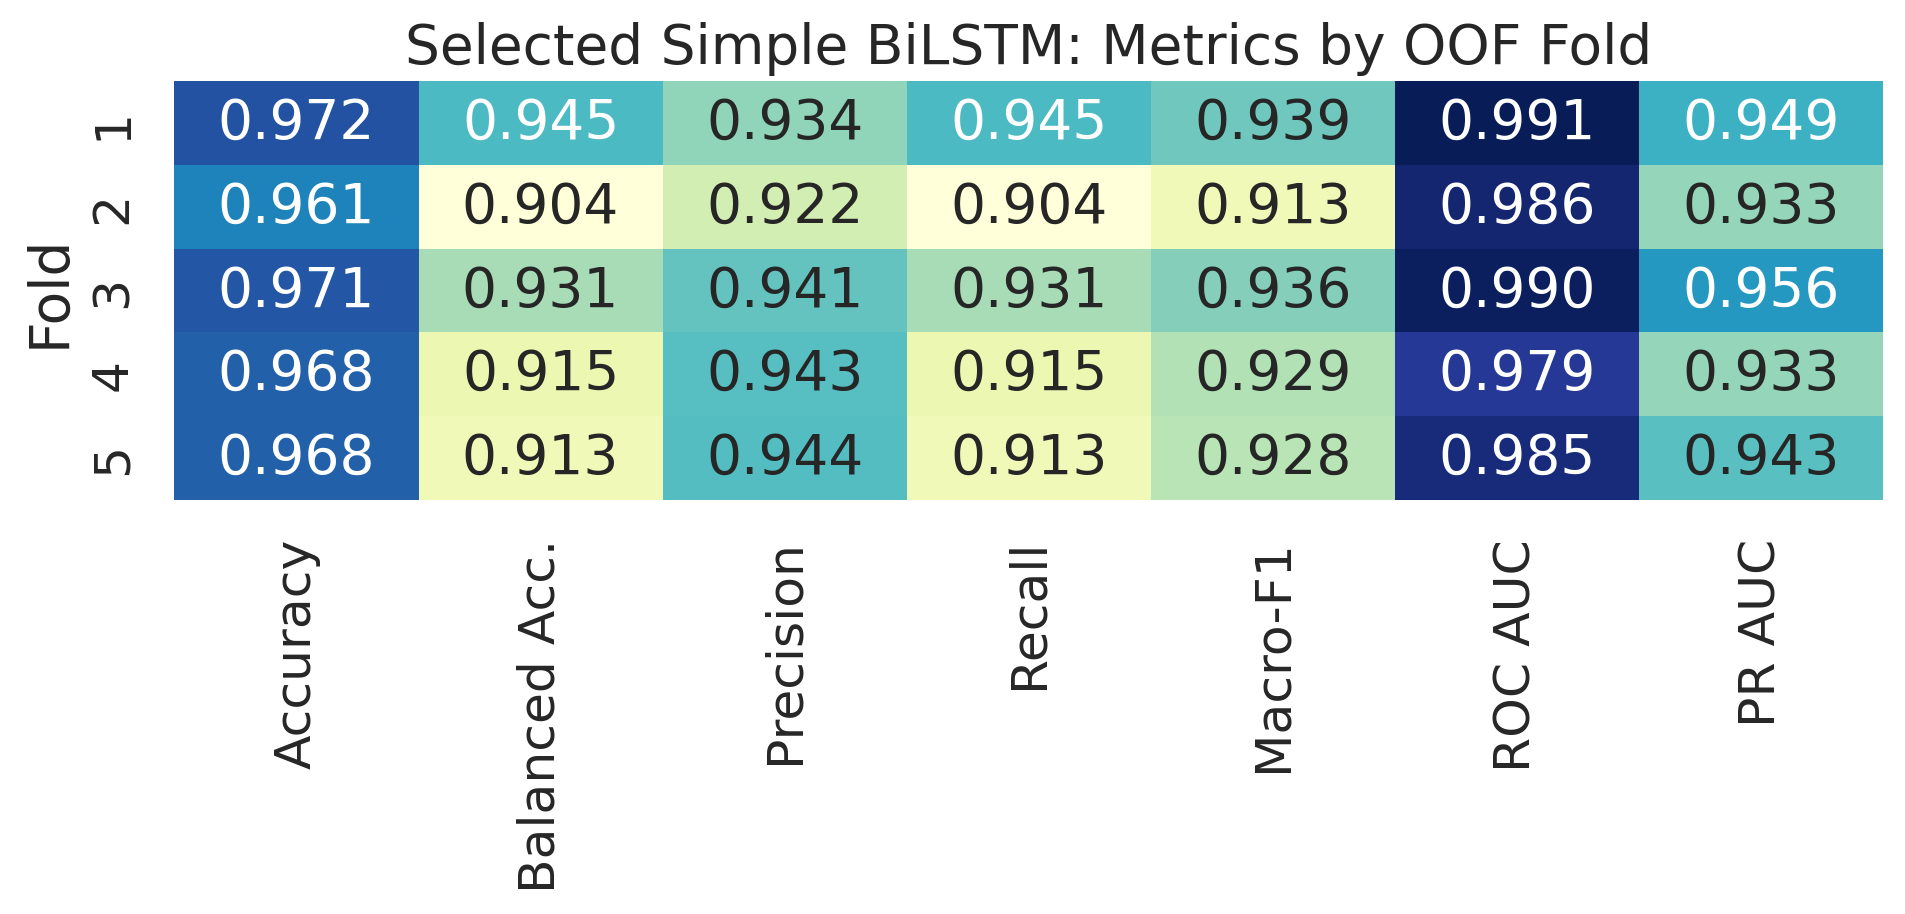

In [6]:
heatmap_frame = best_fold_metrics.set_index("fold")[[
    "accuracy",
    "balanced_accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "roc_auc",
    "pr_auc",
]].rename(columns={
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced Acc.",
    "precision_macro": "Precision",
    "recall_macro": "Recall",
    "f1_macro": "Macro-F1",
    "roc_auc": "ROC AUC",
    "pr_auc": "PR AUC",
})

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(heatmap_frame, annot=True, fmt=".3f", cmap="YlGnBu", cbar=False, ax=ax)
ax.set_title("Selected Simple BiLSTM: Metrics by OOF Fold")
ax.set_xlabel("")
ax.set_ylabel("Fold")
fig.tight_layout()
render_figure(fig)
plt.close(fig)
# save_figure(fig, "simple_fold_metrics_heatmap_custom")


## 5. ROC and Precision-Recall Curves

These curves summarize the discrimination quality of the selected simple BiLSTM on its out-of-fold predictions.


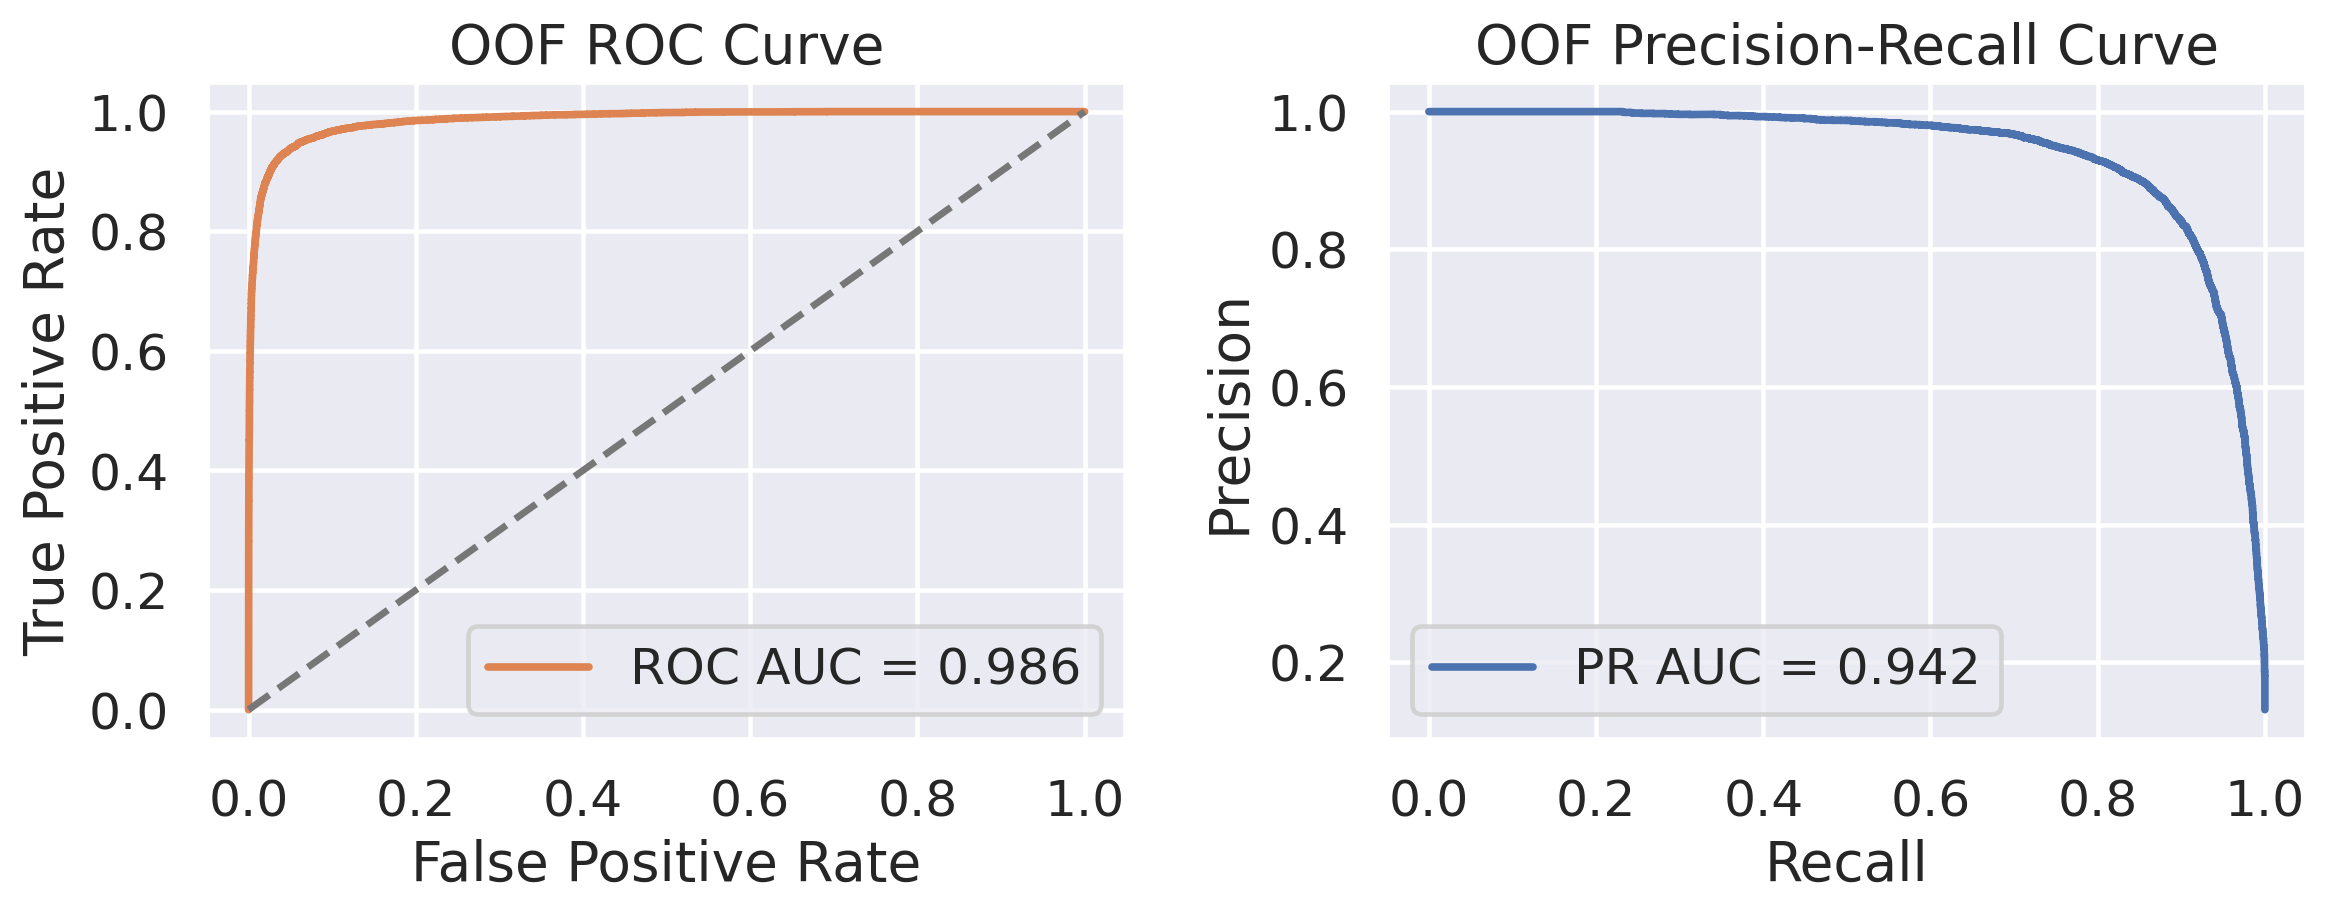

In [7]:
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve

y_true_binary = assets.as_binary_mitterrand(best_run_oof["true_label"].to_numpy(dtype=np.int64))
scores = best_run_oof["prob_mitterrand_raw"].to_numpy(dtype=np.float64)
fpr, tpr, _ = roc_curve(y_true_binary, scores)
precision, recall, _ = precision_recall_curve(y_true_binary, scores)
auc_roc = roc_auc_score(y_true_binary, scores)
auc_pr = average_precision_score(y_true_binary, scores)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, color="#dd8452", linewidth=2.5, label=f"ROC AUC = {auc_roc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="#777777")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("OOF ROC Curve")
axes[0].legend(loc="lower right")

axes[1].plot(recall, precision, color="#4c72b0", linewidth=2.5, label=f"PR AUC = {auc_pr:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("OOF Precision-Recall Curve")
axes[1].legend(loc="lower left")
fig.tight_layout()
render_figure(fig)
plt.close(fig)
# save_figure(fig, "simple_roc_pr_curves_custom")


## 6. Boundary Diagnostics

This histogram summarizes the boundary lag distribution of the clean simple BiLSTM rerun.


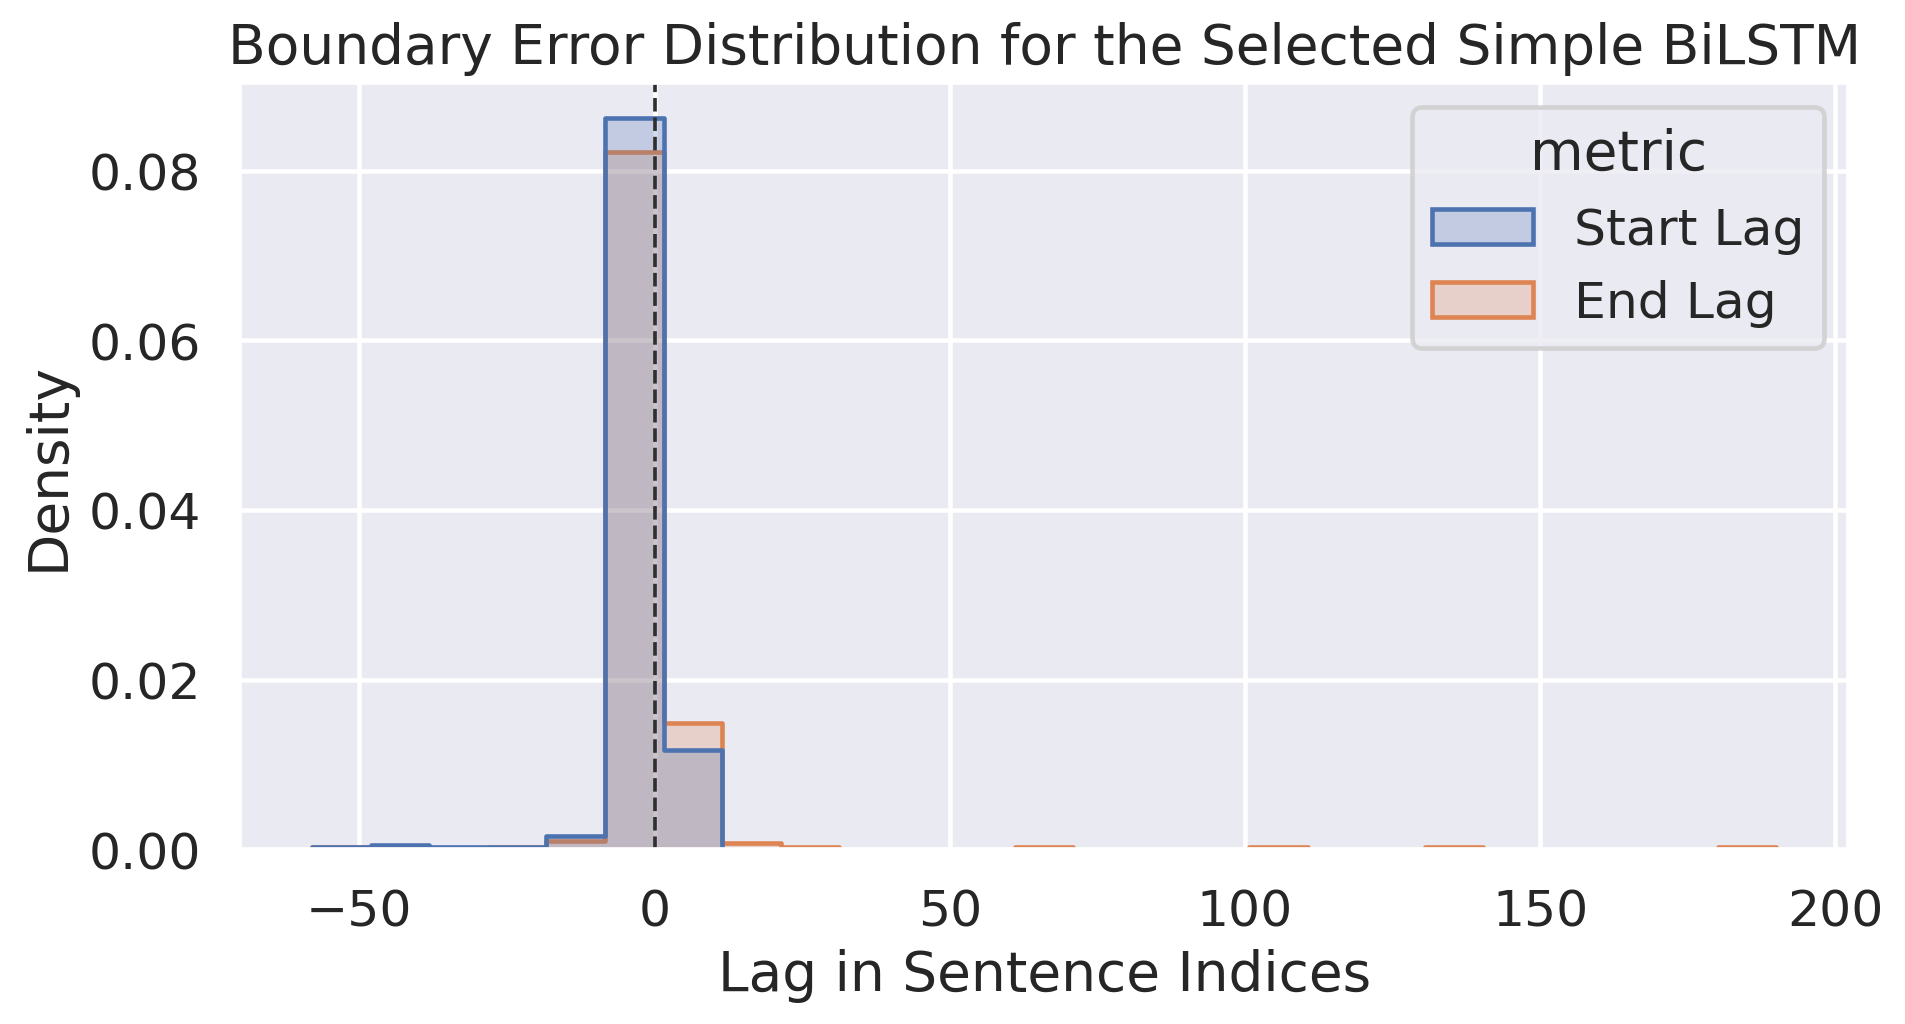

In [8]:
lag_frame = speech_metrics[["start_lag", "end_lag"]].melt(var_name="metric", value_name="lag").dropna()
lag_frame["metric"] = lag_frame["metric"].replace({"start_lag": "Start Lag", "end_lag": "End Lag"})

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=lag_frame,
    x="lag",
    hue="metric",
    element="step",
    stat="density",
    common_norm=False,
    bins=25,
    ax=ax,
)
ax.axvline(0, color="#2f2f2f", linestyle="--", linewidth=1.2)
ax.set_xlabel("Lag in Sentence Indices")
ax.set_title("Boundary Error Distribution for the Selected Simple BiLSTM")
fig.tight_layout()
render_figure(fig)
plt.close(fig)
# save_figure(fig, "simple_boundary_lags_custom")


## 7. Sentence-Level Probability Trajectories

These two examples compare the calibrated simple BiLSTM, CamemBERT, and weighted fusion on representative speeches from the training set.


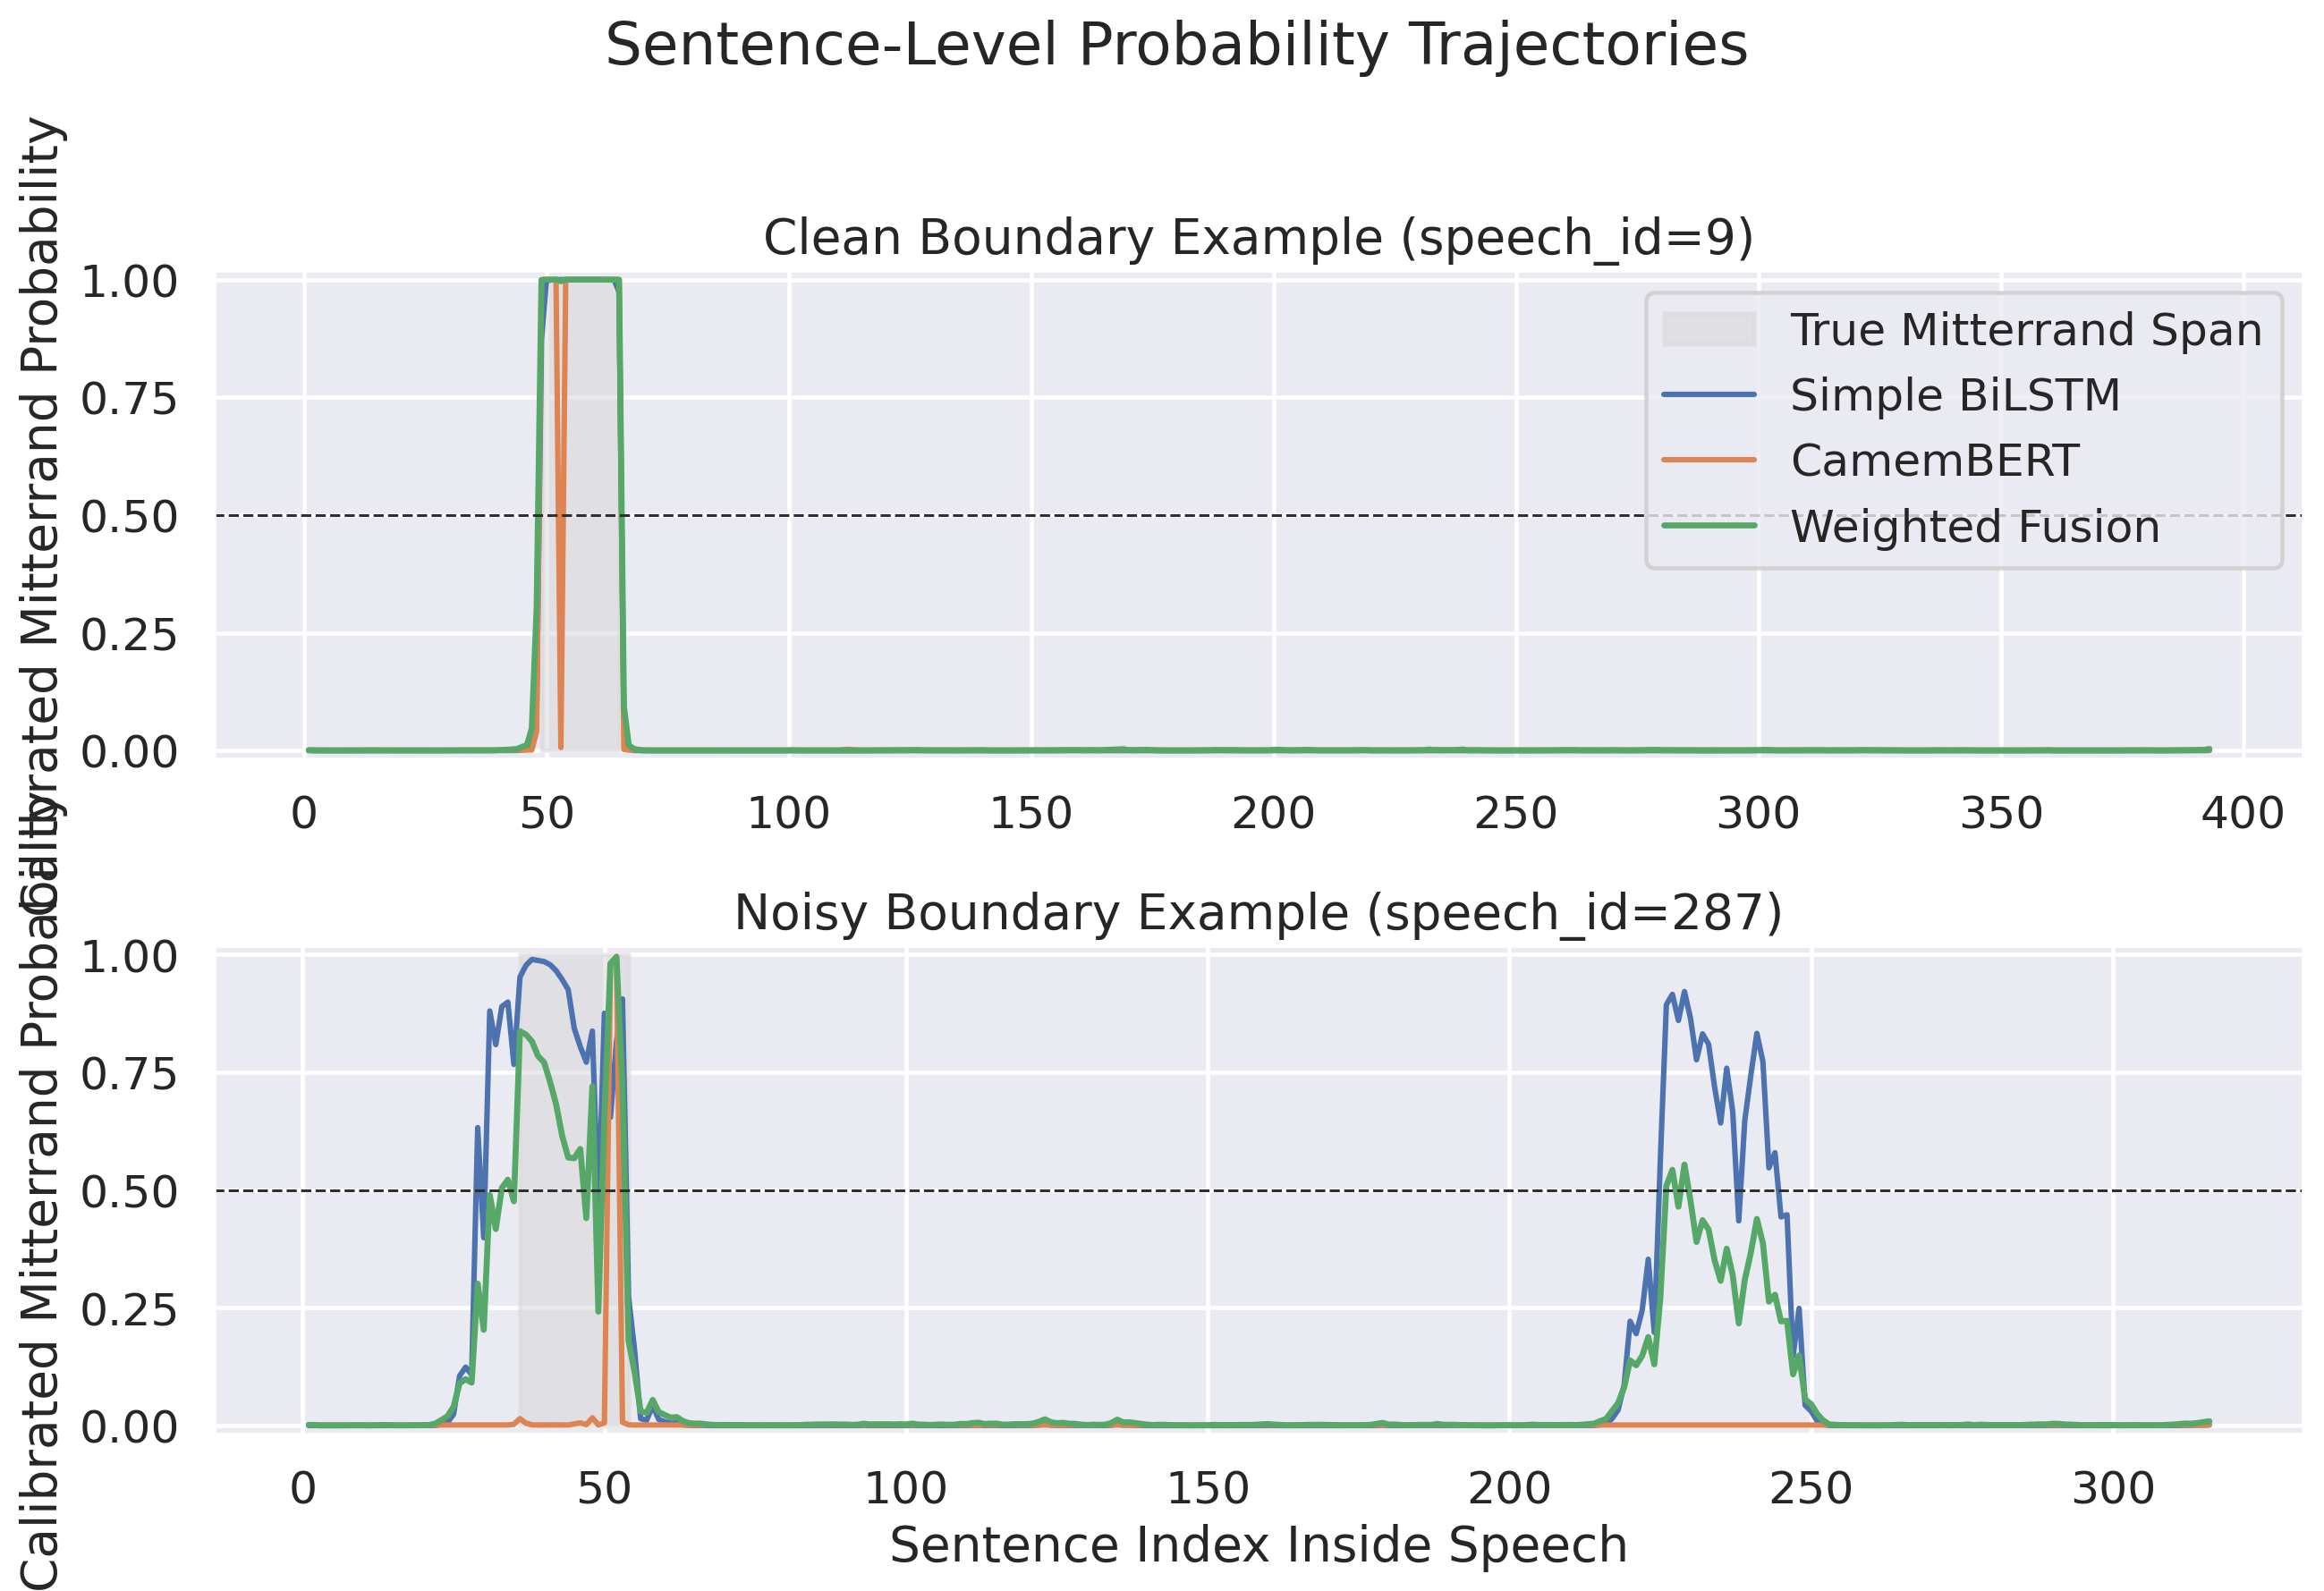

In [9]:
speech_ids = (clean_example_speech, noisy_example_speech)
titles = {
    speech_ids[0]: "Clean Boundary Example",
    speech_ids[1]: "Noisy Boundary Example",
}

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharey=True)
for ax, speech_id in zip(axes, speech_ids):
    group = trajectory_frame[trajectory_frame["speech_id"] == speech_id].sort_values("sentence_id")
    x = group["sentence_id"].to_numpy(dtype=np.int64)
    true_mask = group["true_label"].to_numpy(dtype=np.int64) == -1

    ax.fill_between(
        x,
        0.0,
        1.0,
        where=true_mask,
        color="#d9d9d9",
        alpha=0.55,
        step="mid",
        label="True Mitterrand Span",
    )
    ax.plot(x, group["prob_simple_calibrated"], color="#4c72b0", linewidth=2.0, label="Simple BiLSTM")
    ax.plot(x, group["prob_camembert_calibrated"], color="#dd8452", linewidth=2.0, label="CamemBERT")
    ax.plot(x, group["prob_fusion_calibrated"], color="#55a868", linewidth=2.2, label="Weighted Fusion")
    ax.axhline(0.5, color="#2f2f2f", linestyle="--", linewidth=1.0)
    ax.set_title(f"{titles[speech_id]} (speech_id={speech_id})")
    ax.set_ylabel("Calibrated Mitterrand Probability")
    ax.set_ylim(-0.02, 1.02)

axes[-1].set_xlabel("Sentence Index Inside Speech")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, loc="upper right")
fig.suptitle("Sentence-Level Probability Trajectories", y=1.02)
fig.tight_layout()
render_figure(fig)
plt.close(fig)
# save_figure(fig, "probability_trajectories_examples_custom")


## 8. Model Comparison on Out-of-Fold Predictions

This bar chart compares the main models on the same grouped out-of-fold evaluation setup.


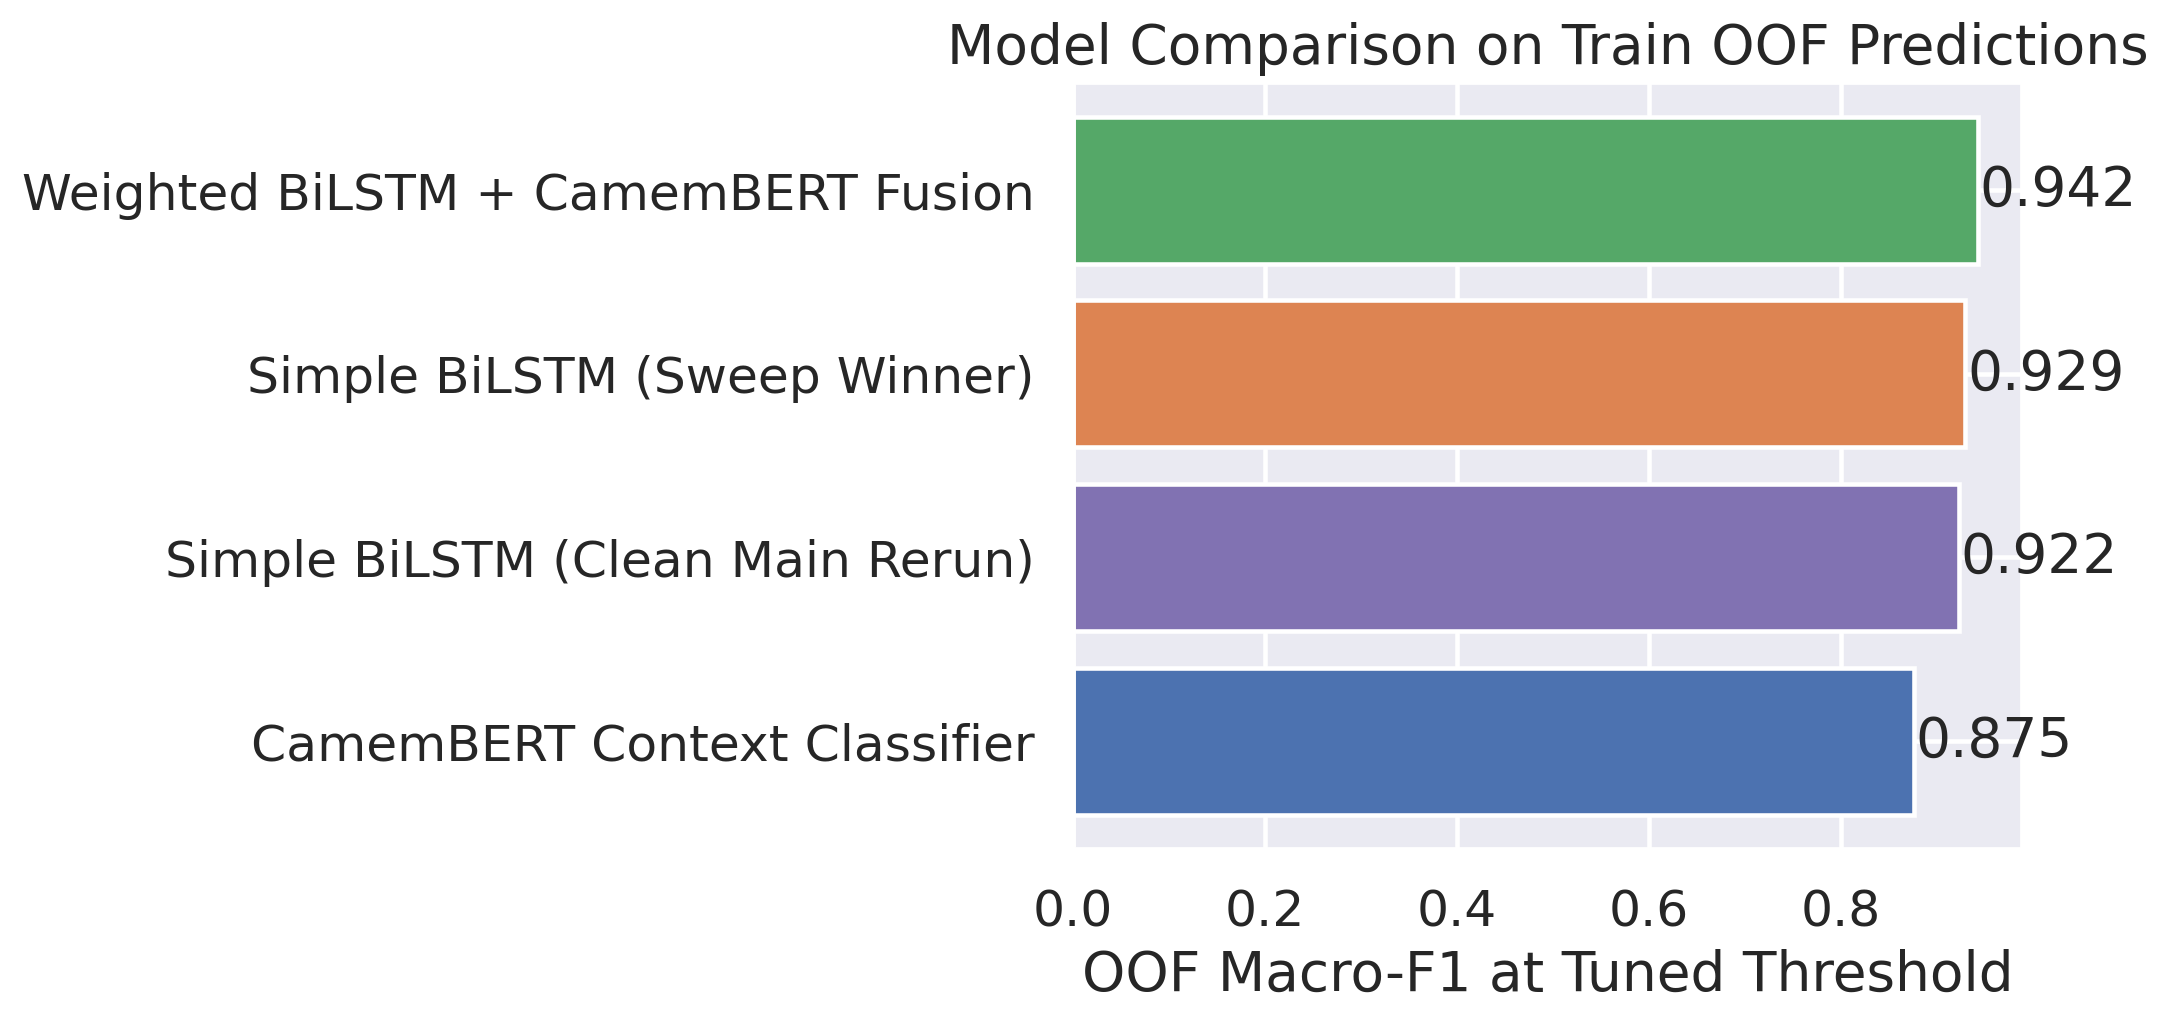

In [10]:
plot_frame = model_comparison_frame.sort_values("oof_f1_macro", ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(plot_frame["model"], plot_frame["oof_f1_macro"], color=["#4c72b0", "#8172b2", "#dd8452", "#55a868"])
ax.set_xlabel("OOF Macro-F1 at Tuned Threshold")
ax.set_title("Model Comparison on Train OOF Predictions")
for _, row in plot_frame.iterrows():
    ax.text(row["oof_f1_macro"] + 0.002, row["model"], f"{row['oof_f1_macro']:.3f}", va="center")
fig.tight_layout()
render_figure(fig)
plt.close(fig)
# save_figure(fig, "model_comparison_oof_custom")


## 9. Fusion Weight Sweep

This plot shows how the weighted-average fusion performs as the BiLSTM weight varies.


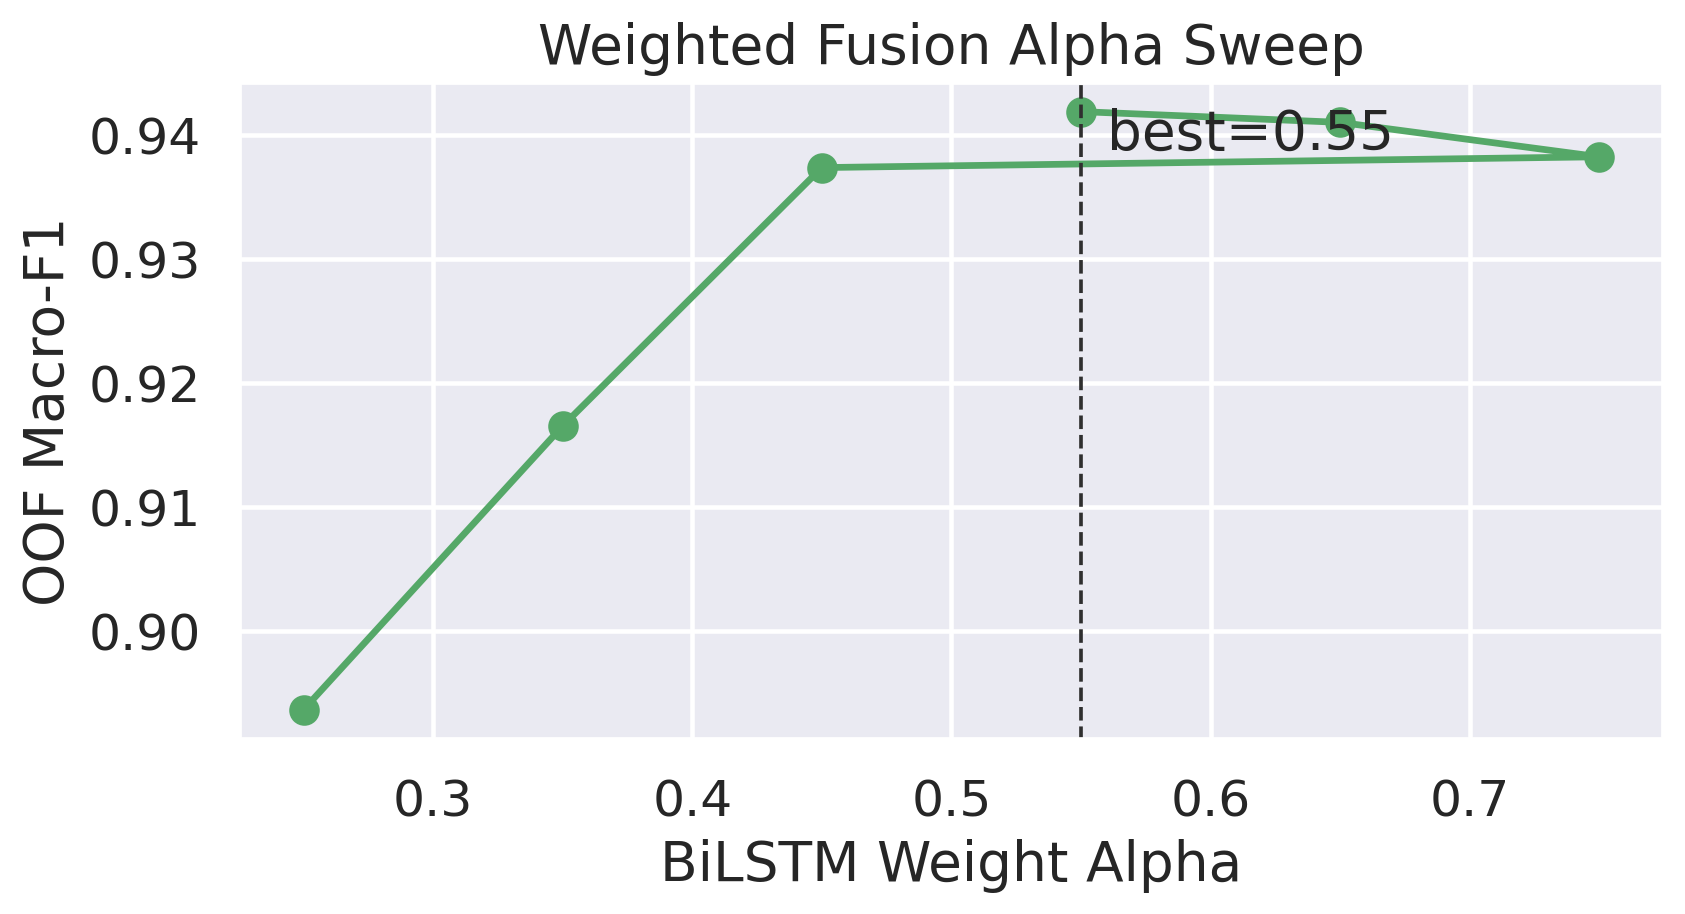

In [11]:
alpha_sweep = pd.read_csv(fusion_source_dir / "alpha_sweep.csv")
best_alpha_row = alpha_sweep.sort_values(["f1_macro", "balanced_accuracy", "alpha"], ascending=[False, False, True]).iloc[0]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(alpha_sweep["alpha"], alpha_sweep["f1_macro"], marker="o", linewidth=2.2, color="#55a868")
ax.axvline(best_alpha_row["alpha"], color="#2f2f2f", linestyle="--", linewidth=1.2)
ax.set_xlabel("BiLSTM Weight Alpha")
ax.set_ylabel("OOF Macro-F1")
ax.set_title("Weighted Fusion Alpha Sweep")
ax.text(float(best_alpha_row["alpha"]) + 0.01, float(best_alpha_row["f1_macro"]) - 0.003, f"best={best_alpha_row['alpha']:.2f}")
fig.tight_layout()
render_figure(fig)
plt.close(fig)
# save_figure(fig, "fusion_alpha_sweep_custom")


## 10. Rebuild the Baseline Bundle

If you want to regenerate the default bundle after manual figure exploration, you can call the batch builder below.


In [12]:
# assets.main()
